## Loan Approval Prediction — Decision Tree Classifier

# Loan Approval Prediction — Decision Tree Classifier
### Mini Project : EDA → Preprocessing → Model Training → Hyperparameter Tuning → Insights

This notebook predicts whether a loan application will be `Approved` or `Rejected` from applicant financial and demographic data (`income`, `cibil_score`, `loan_amount`, asset values, `education`, `self_employed`, etc.), comparing a baseline Decision Tree against a hyperparameter-tuned version and identifying the key drivers of approval.

---
## Module 1: Setup & Data Understanding (EDA)

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              classification_report, confusion_matrix, roc_auc_score, roc_curve)
from sklearn.model_selection import GridSearchCV

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid') 
plt.rcParams['figure.figsize'] = (8, 5) 


In [2]:
df = pd.read_csv("../data/loan_approval_dataset.csv")
df.columns = df.columns.str.strip()
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip()

print("Shape:", df.shape)
df.head()

Shape: (4269, 13)


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [3]:
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   loan_id                   4269 non-null   int64 
 1   no_of_dependents          4269 non-null   int64 
 2   education                 4269 non-null   object
 3   self_employed             4269 non-null   object
 4   income_annum              4269 non-null   int64 
 5   loan_amount               4269 non-null   int64 
 6   loan_term                 4269 non-null   int64 
 7   cibil_score               4269 non-null   int64 
 8   residential_assets_value  4269 non-null   int64 
 9   commercial_assets_value   4269 non-null   int64 
 10  luxury_assets_value       4269 non-null   int64 
 11  bank_asset_value          4269 non-null   int64 
 12  loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [4]:
df.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


In [5]:
df.describe(include='object')

,education,self_employed,loan_status
count,4269,4269,4269
unique,2,2,2
top,Graduate,Yes,Approved
freq,2144,2150,2656


In [6]:
print("Missing values per column:")
print(df.isnull().sum())
print("\nTotal missing values:", df.isnull().sum().sum())

Missing values per column:
loan_id                     0
no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64

Total missing values: 0


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df['loan_status'].value_counts(normalize=True) * 100

loan_status
Approved    62.215976
Rejected    37.784024
Name: proportion, dtype: float64

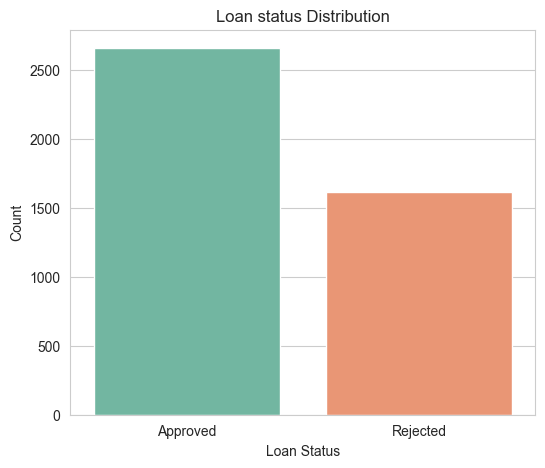

In [9]:
plt.figure(figsize=(6, 5))
sns.countplot(data=df , x='loan_status',hue='loan_status',palette='Set2')
plt.title('Loan status Distribution')
plt.xlabel('Loan Status')
plt.ylabel('Count')
plt.savefig("../images/target_distribution.png")
plt.show()

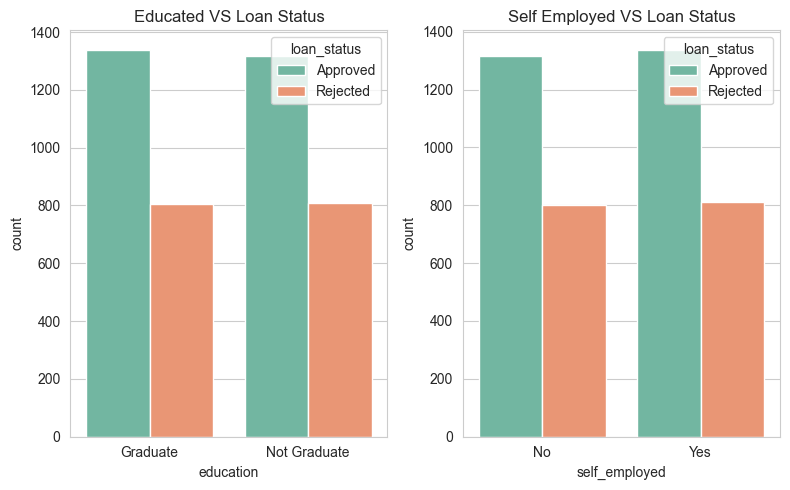

In [10]:
fig , axes = plt.subplots(1,2,figsize=(8,5))
sns.countplot(data=df,x='education',hue='loan_status',ax=axes[0],palette='Set2')
axes[0].set_title('Educated VS Loan Status')
sns.countplot(data=df,x='self_employed',hue='loan_status',ax=axes[1],palette='Set2')
axes[1].set_title('Self Employed VS Loan Status')
plt.tight_layout()
plt.show()

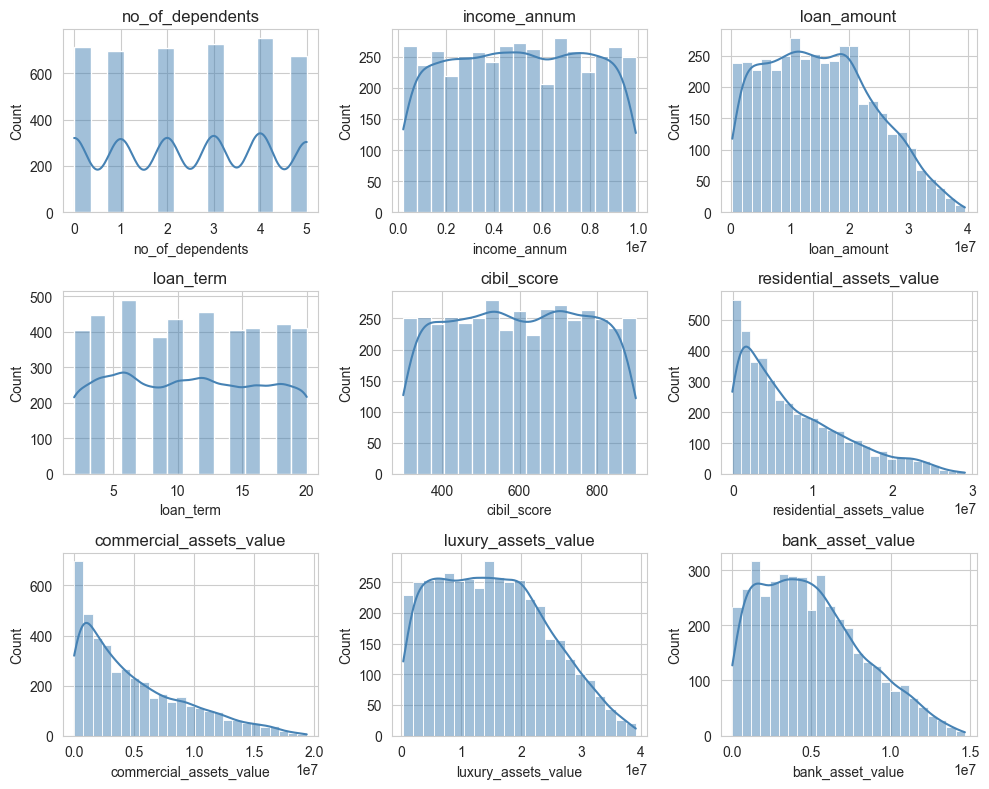

In [11]:
num_cols = ['no_of_dependents', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
            'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']

fig, axes = plt.subplots(3, 3, figsize=(10, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(col)
plt.tight_layout()
plt.savefig("../images/distribution_of_numeric_feature.png")
plt.show()

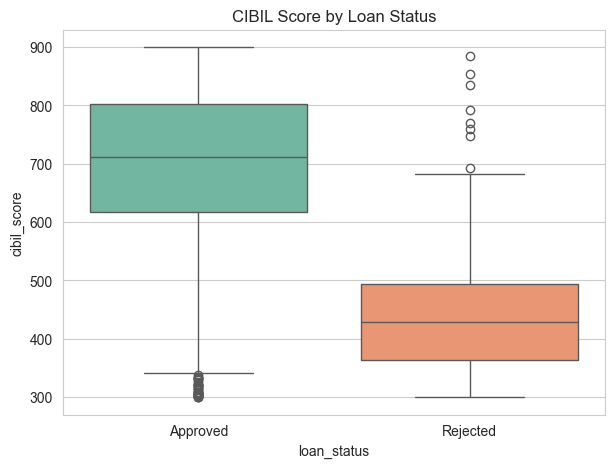

,count,mean,std,min,25%,50%,75%,max
loan_status,,,,,,,,
Approved,2656.0,703.461973,125.249016,300.0,618.0,711.0,803.0,900.0
Rejected,1613.0,429.468072,78.401752,300.0,364.0,429.0,493.0,885.0


In [12]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='loan_status', y='cibil_score', hue='loan_status', palette='Set2', legend=False)
plt.title('CIBIL Score by Loan Status')
plt.show()  
df.groupby('loan_status')['cibil_score'].describe()

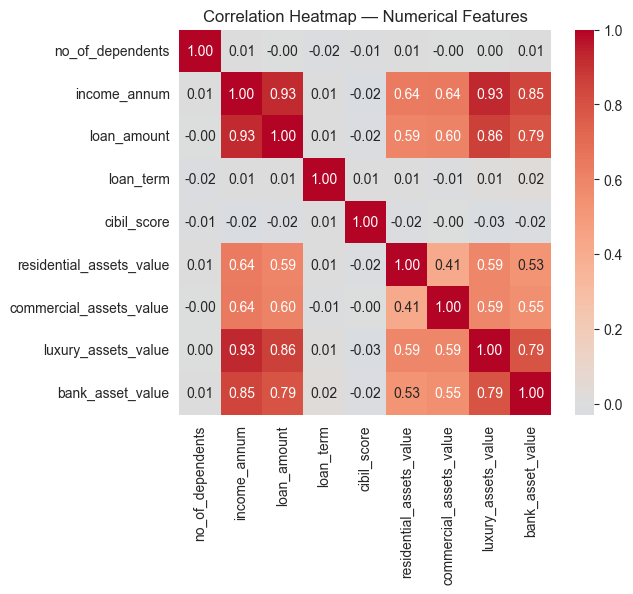

In [13]:
plt.figure(figsize=(6, 5))
corr = df[num_cols].corr()   
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap — Numerical Features')
plt.savefig("../images/correlation_heatmap.png")
plt.show()

**Module 1 EDA Key Insights**
- 4,269 rows, 13 columns, **zero missing and duplicates values** — clean dataset, no imputation needed
- Target is mildly imbalanced: **62.2% Approved vs 37.8% Rejected** — will track Precision/Recall/F1 in evaluation, not just accuracy
- **`cibil_score` shows the strongest separation of any feature** — Approved applicants average 703 (±125), Rejected average 429 (±78), a ~274-point gap. Strong early signal this will dominate feature importance in Module 4
- `education` and `self_employed` show no visible standalone effect on approval — both classes split roughly evenly across these categories
- Asset value columns are right-skewed, as expected for financial data (few very high-asset applicants)

## Module 2 — Preprocessing Pipeline

In [14]:
df_model = df.drop(columns=['loan_id'])

# Encode categorical columns to numeric
df_model['education'] = df_model['education'].map({'Graduate': 1, 'Not Graduate': 0})
df_model['self_employed'] = df_model['self_employed'].map({'Yes': 1, 'No': 0})
df_model['loan_status'] = df_model['loan_status'].map({'Approved': 1, 'Rejected': 0})

df_model.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,1,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,1
1,0,0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0
2,3,1,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0
3,3,1,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0
4,5,0,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0


In [15]:
print(df_model.isnull().sum().sum(), "missing values after encoding")
df_model.dtypes

0 missing values after encoding


no_of_dependents            int64
education                   int64
self_employed               int64
income_annum                int64
loan_amount                 int64
loan_term                   int64
cibil_score                 int64
residential_assets_value    int64
commercial_assets_value     int64
luxury_assets_value         int64
bank_asset_value            int64
loan_status                 int64
dtype: object

In [16]:
X= df_model.drop('loan_status',axis=1)
y = df_model['loan_status']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)


Train shape: (3415, 11) Test shape: (854, 11)


In [17]:
print("Train class balance:")
print(y_train.value_counts(normalize=True))
print("\nTest class balance:")
print(y_test.value_counts(normalize=True))

Train class balance:
loan_status
1    0.622255
0    0.377745
Name: proportion, dtype: float64

Test class balance:
loan_status
1    0.62178
0    0.37822
Name: proportion, dtype: float64


**Module 2 Summary**
- Dropped `loan_id` (non-predictive identifier)
- Encoded `education`, `self_employed`, `loan_status` to numeric (0/1)
- Stratified 80/20 split — **3,415 train / 854 test**, preserving the ~62/38 class ratio from Module 1
- **No feature scaling applied** — Decision Trees split on thresholds (`is cibil_score > X?`), so unlike other models, scale doesn't affect the model

## Module 3 — Baseline Model & Evaluation

In [18]:
baseline_model = DecisionTreeClassifier(random_state=42)
baseline_model.fit(X_train, y_train)

train_pred = baseline_model.predict(X_train)
test_pred = baseline_model.predict(X_test)

train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)

print(f"Baseline Train Accuracy: {train_acc:.4f}")
print(f"Baseline Test Accuracy:  {test_acc:.4f}")
print(f"Accuracy Gap : {train_acc - test_acc:.4f}")
print(f"\nTree depth used: {baseline_model.get_depth()}")
print(f"Number of leaves: {baseline_model.get_n_leaves()}")

Baseline Train Accuracy: 1.0000
Baseline Test Accuracy:  0.9813
Accuracy Gap : 0.0187

Tree depth used: 15
Number of leaves: 53


In [19]:
print("Classification Report (Test Set):\n")
print(classification_report(y_test, test_pred, target_names=['Rejected', 'Approved']))

Classification Report (Test Set):

              precision    recall  f1-score   support

    Rejected       0.98      0.98      0.98       323
    Approved       0.98      0.98      0.98       531

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854



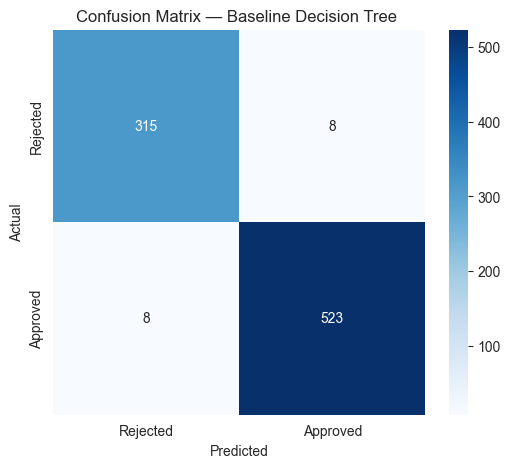

In [20]:
cm = confusion_matrix(y_test, test_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Rejected', 'Approved'], yticklabels=['Rejected', 'Approved'])
plt.title('Confusion Matrix — Baseline Decision Tree ')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig("../images/confusion_matrix.png")
plt.show()

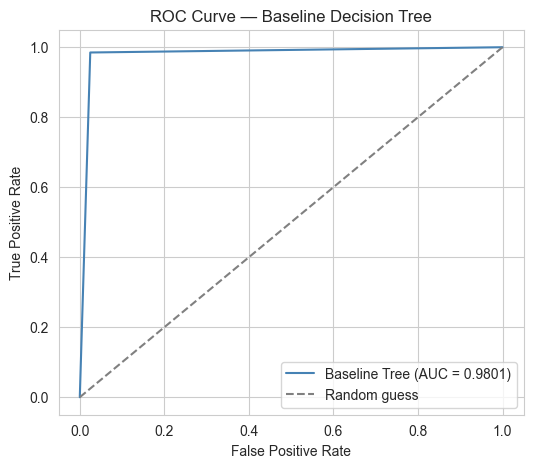

ROC-AUC Score: 0.9801


In [21]:
test_proba = baseline_model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, test_proba)
fpr, tpr, _ = roc_curve(y_test, test_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'Baseline Tree (AUC = {roc_auc:.4f})', color='steelblue')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Baseline Decision Tree')
plt.legend()
plt.savefig('../images/roc_curve_baseline.png')
plt.show()

print(f"ROC-AUC Score: {roc_auc:.4f}")

**Module 3 Summary**
- Baseline (fully-grown, unpruned) tree hit **100% train accuracy but only 98.13% test accuracy** — a **1.87-point overfitting gap**, exactly the pattern flagged in the Decision Tree theory notes for an unrestricted tree (depth 15, 53 leaves)
- Test set: **Precision/Recall/F1 all 0.9849, ROC-AUC 0.9801** — already strong, but the train-test gap is the thing worth fixing next via pruning/tuning

## Module 4 — Hyperparameter Tuning & Feature Importance

In [22]:
param_grid = {
    'max_depth': [3, 4, 5, 6, 7, 8, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 5, 10, 20],
    'criterion': ['gini', 'entropy']}
grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1)
grid_search.fit(X_train, y_train)
print("Best parameters found:",grid_search.best_params_)
print(f"\nBest cv F1 score: {grid_search.best_score_:.4f}")

Best parameters found: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 5, 'min_samples_split': 2}

Best cv F1 score: 0.9838


In [23]:
tuned_model = grid_search.best_estimator_

tuned_train_pred = tuned_model.predict(X_train)
tuned_test_pred = tuned_model.predict(X_test)

tuned_train_acc = accuracy_score(y_train, tuned_train_pred)
tuned_test_acc = accuracy_score(y_test, tuned_test_pred)

print(f"Tuned Train Accuracy: {tuned_train_acc:.4f}")
print(f"Tuned Test Accuracy:  {tuned_test_acc:.4f}")
print(f"Accuracy Gap : {tuned_train_acc - tuned_test_acc:.4f}")
print(f"Tree depth used: {tuned_model.get_depth()}")
print(f"Number of leaves: {tuned_model.get_n_leaves()}")

Tuned Train Accuracy: 0.9933
Tuned Test Accuracy:  0.9824
Accuracy Gap : 0.0108
Tree depth used: 15
Number of leaves: 39


In [24]:
print("Classification Report — Tuned Model (Test Set):\n")
print(classification_report(y_test, tuned_test_pred, target_names=['Rejected', 'Approved']))

Classification Report — Tuned Model (Test Set):

              precision    recall  f1-score   support

    Rejected       0.98      0.97      0.98       323
    Approved       0.98      0.99      0.99       531

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854



In [25]:
tuned_proba = tuned_model.predict_proba(X_test)[:, 1]
tuned_roc_auc = roc_auc_score(y_test, tuned_proba)

comparison = pd.DataFrame({
    'Metric': ['Train Accuracy', 'Test Accuracy', 'Train-Test Gap', 'Test Precision', 'Test Recall', 'Test F1', 'Test ROC-AUC'],
    'Baseline': [
        train_acc, test_acc, train_acc - test_acc,
        precision_score(y_test, test_pred), recall_score(y_test, test_pred),
        f1_score(y_test, test_pred), roc_auc ],
    'Tuned': [
        tuned_train_acc, tuned_test_acc, tuned_train_acc - tuned_test_acc,
        precision_score(y_test, tuned_test_pred), recall_score(y_test, tuned_test_pred),
        f1_score(y_test, tuned_test_pred), tuned_roc_auc]})
comparison['Baseline'] = comparison['Baseline'].round(4)
comparison['Tuned'] = comparison['Tuned'].round(4)
comparison

,Metric,Baseline,Tuned
0,Train Accuracy,1.0000,0.9933
1,Test Accuracy,0.9813,0.9824
2,Train-Test Gap,0.0187,0.0108
3,Test Precision,0.9849,0.9813
4,Test Recall,0.9849,0.9906
5,Test F1,0.9849,0.9859
6,Test ROC-AUC,0.9801,0.9839


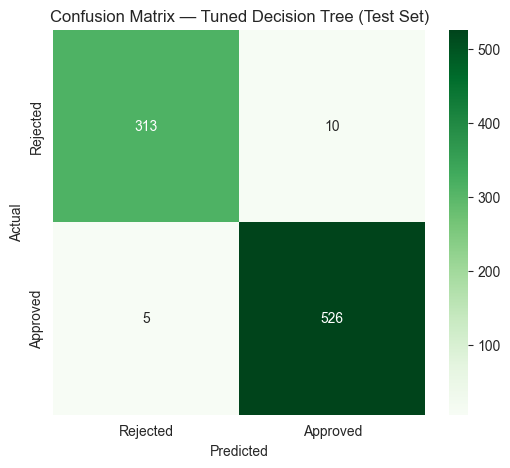

In [26]:
cm_tuned = confusion_matrix(y_test, tuned_test_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Rejected', 'Approved'], yticklabels=['Rejected', 'Approved'])
plt.title('Confusion Matrix — Tuned Decision Tree (Test Set)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig("../images/confusion_matrix_tuned.png")
plt.show()

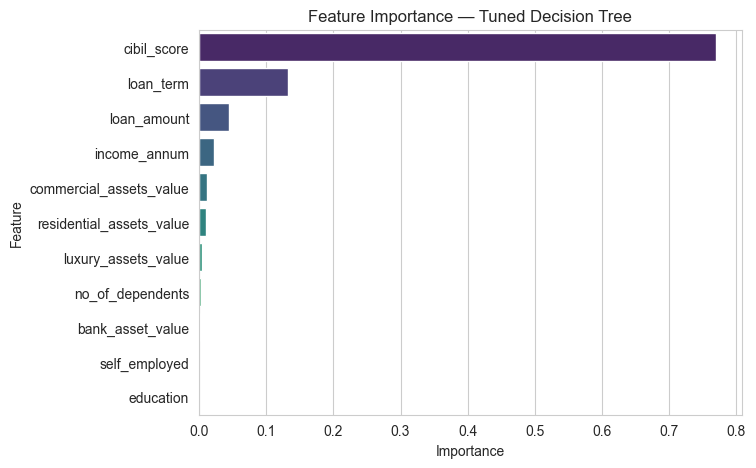

,Feature,Importance
6,cibil_score,0.769119
5,loan_term,0.132576
4,loan_amount,0.044643
3,income_annum,0.022782
8,commercial_assets_value,0.012414
7,residential_assets_value,0.010606
9,luxury_assets_value,0.004002
0,no_of_dependents,0.002734
10,bank_asset_value,0.001123
2,self_employed,0.000000


In [27]:
importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': tuned_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(7, 5))
sns.barplot(data=importances, x='Importance', y='Feature', hue='Feature', palette='viridis', legend=False)
plt.title('Feature Importance — Tuned Decision Tree')
plt.savefig('../images/feature_importance.png')
plt.show() 
importances 

**Module 4 Summary**
- `GridSearchCV` (5-fold CV, optimizing F1) selected **`criterion='entropy'`, `min_samples_leaf=5`, `min_samples_split=2`, `max_depth=None`**
- Tuned tree: test accuracy improved marginally to **98.24%**, but the **train-test gap shrank from 1.87% to 1.08%** — a leaner tree (39 leaves vs. 53) that generalizes better, not just a bigger one
- **`cibil_score` alone accounts for ~77% of feature importance**, `loan_term` a distant second (~13%) — confirms the Module 1 EDA finding with an exact number
- `education` and `self_employed` show **~0% importance** — the model essentially ignores them, matching the "no visible effect" observation from Module 1

## Module 5 — Insights & Conclusion

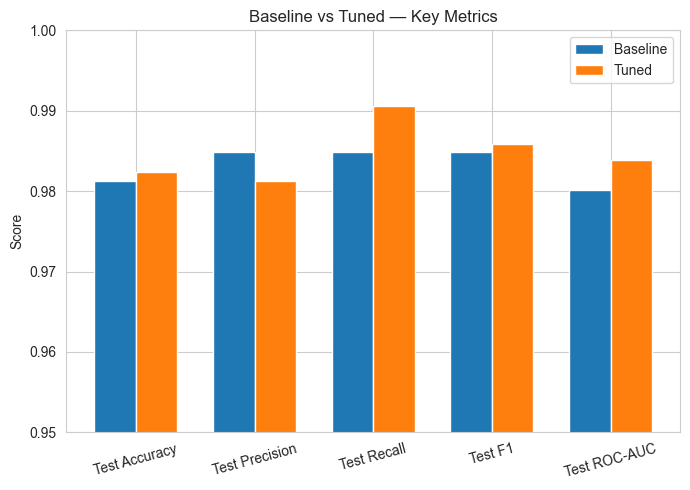

In [28]:
metrics = ['Test Accuracy', 'Test Precision', 'Test Recall', 'Test F1', 'Test ROC-AUC']
baseline_vals = comparison.set_index('Metric').loc[metrics, 'Baseline'].values
tuned_vals = comparison.set_index('Metric').loc[metrics, 'Tuned'].values
x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(7,5))
plt.bar(x - width/2, baseline_vals, width, label='Baseline')
plt.bar(x + width/2, tuned_vals, width, label='Tuned')
plt.xticks(x, metrics, rotation=15)
plt.ylim(0.95, 1.0) 
plt.ylabel('Score') 
plt.title('Baseline vs Tuned — Key Metrics')
plt.legend()
plt.tight_layout()
plt.savefig("../images/baseline_vs_tuned_metrics.png")
plt.show()

**Final Model Scorecard**

| Metric | Baseline | Tuned | Change |
|---|---|---|---|
| Test Accuracy | 98.13% | 98.24% | +0.11 pp |
| Train-Test Gap | 1.87% | 1.08% | −0.79 pp (less overfitting) |
| Test F1 | 0.9849 | 0.9859 | +0.0010 |
| Test ROC-AUC | 0.9801 | 0.9839 | +0.0038 |

**Root driver:** `cibil_score` alone explains ~77% of the model's decisions — in this dataset, loan approval is overwhelmingly a function of credit score, not income, assets, or demographics. Every other feature combined barely moves the needle.

**Business takeaway:** a Decision Tree this shallow-in-spirit (one dominant feature) is easy to explain to a compliance/risk team — "this application was rejected primarily because of a low CIBIL score" is a defensible, auditable reason. That interpretability is exactly what makes trees attractive for loan approval use cases specifically, even though ensembles usually edge out a single tree on raw accuracy.

**A caveat worth being upfront about:** 98%+ accuracy with one feature explaining 77% of the decision is *very* clean for real-world lending data — real credit approval usually involves messier, more overlapping signals. This is a strong hint the dataset may be synthetically generated or built around a simplified approval rule, rather than genuine historical lending outcomes. Worth keeping in mind when describing this project's results — the pipeline and methodology are solid, but the near-perfect separability likely says more about the dataset than about how predictable real-world loan approval actually is.

**Next step (future work):** compare against Random Forest / Gradient Boosting to check whether ensembling changes which features matter, and sanity-check the dataset's provenance if this project is used as a portfolio piece.